# **0. Análisis Exploratorio de Datos**

In [1]:
import os
import glob
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110

# Rutas relativas al proyecto
BASE = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'data'))
ATTACK_DIR  = os.path.join(BASE, 'attack_traffic')
NORMAL_DIR  = os.path.join(BASE, 'normal_traffic')
print('Base data dir:', BASE)

Base data dir: /home/nico/Desktop/Anomaly-Detection-IoT/data


## 1. Inventario de archivos

In [2]:
attack_files  = sorted(glob.glob(os.path.join(ATTACK_DIR, '*.csv')))
normal_files  = sorted(glob.glob(os.path.join(NORMAL_DIR, '*', '*.csv')))

def file_info(paths):
    rows = []
    for p in paths:
        size_mb = os.path.getsize(p) / 1e6
        rows.append({'archivo': os.path.basename(p), 'tamaño_MB': round(size_mb, 2), 'ruta': p})
    return pd.DataFrame(rows)

print(f'Archivos de ataque  : {len(attack_files)}')
print(f'Archivos normales   : {len(normal_files)}')
display(file_info(attack_files))
display(file_info(normal_files))

Archivos de ataque  : 14
Archivos normales   : 10


,archivo,tamaño_MB,ruta
0,Backdoor_attack.csv,17.89,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
1,DDoS_HTTP_Flood_attack.csv,95.71,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
2,DDoS_ICMP_Flood_attack.csv,892.08,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
3,DDoS_TCP_SYN_Flood_attack.csv,941.19,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
4,DDoS_UDP_Flood_attack.csv,900.23,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
5,MITM_attack.csv,0.33,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
6,OS_Fingerprinting_attack.csv,0.31,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
7,Password_attack.csv,653.29,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
8,Port_Scanning_attack.csv,7.34,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
9,Ransomware_attack.csv,7.59,/home/nico/Desktop/Anomaly-Detection-IoT/data/...


,archivo,tamaño_MB,ruta
0,Distance.csv,366.06,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
1,Flame_Sensor.csv,343.52,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
2,Heart_Rate.csv,52.57,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
3,IR_Receiver.csv,412.74,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
4,Modbus.csv,67.90,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
5,Soil_Moisture.csv,381.59,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
6,Sound_Sensor.csv,478.97,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
7,Temperature_and_Humidity.csv,922.59,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
8,Water_Level.csv,731.46,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
9,phValue.csv,237.33,/home/nico/Desktop/Anomaly-Detection-IoT/data/...


## 2. Carga y conteo de registros por archivo

In [3]:
def count_rows(paths, label):
    records = []
    for p in paths:
        name = os.path.basename(p).replace('.csv', '')
        n = sum(1 for _ in open(p)) - 1  # rápido, sin cargar todo en memoria
        records.append({'tipo': label, 'dataset': name, 'registros': n})
    return pd.DataFrame(records)

df_counts_attack = count_rows(attack_files, 'Ataque')
df_counts_normal = count_rows(normal_files, 'Normal')
df_counts = pd.concat([df_counts_attack, df_counts_normal], ignore_index=True)

display(df_counts.sort_values('registros', ascending=False))

,tipo,dataset,registros
4,Ataque,DDoS_UDP_Flood_attack,3201626
2,Ataque,DDoS_ICMP_Flood_attack,2914354
22,Normal,Water_Level,2295288
3,Ataque,DDoS_TCP_SYN_Flood_attack,2020120
21,Normal,Temperature_and_Humidity,1615722
20,Normal,Sound_Sensor,1512883
17,Normal,IR_Receiver,1307778
19,Normal,Soil_Moisture,1192777
14,Normal,Distance,1143540
15,Normal,Flame_Sensor,1070196


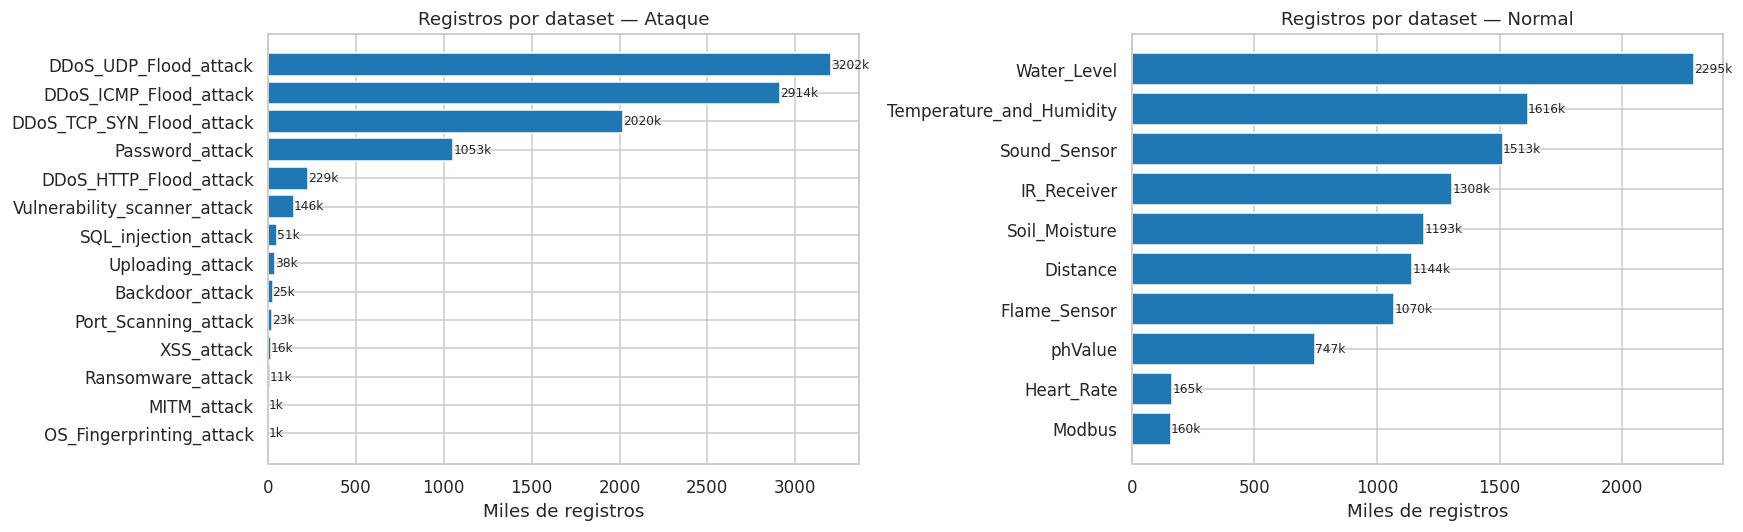

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (label, grp) in zip(axes, df_counts.groupby('tipo')):
    grp_sorted = grp.sort_values('registros', ascending=True)
    bars = ax.barh(grp_sorted['dataset'], grp_sorted['registros'] / 1e3)
    ax.set_xlabel('Miles de registros')
    ax.set_title(f'Registros por dataset — {label}')
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.5, bar.get_y() + bar.get_height()/2,
                f'{w:.0f}k', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 3. Carga completa del dataset combinado

> Los archivos grandes (DDoS UDP/TCP/ICMP) se muestrean para agilizar el análisis.

In [5]:
SAMPLE_THRESHOLD = 500_000  # filas: si el archivo supera esto, se muestrea
SAMPLE_N         = 100_000

def load_csv(path):
    n_rows = sum(1 for _ in open(path)) - 1
    if n_rows > SAMPLE_THRESHOLD:
        df = pd.read_csv(path, skiprows=lambda i: i > 0 and np.random.rand() > SAMPLE_N / n_rows,
                         low_memory=False)
        print(f'  [muestreado] {os.path.basename(path)}: {n_rows:,} → {len(df):,} filas')
    else:
        df = pd.read_csv(path, low_memory=False)
    return df

print('Cargando archivos de ataque...')
parts_attack = [load_csv(p) for p in attack_files]

print('Cargando archivos normales...')
parts_normal = [load_csv(p) for p in normal_files]

df = pd.concat(parts_attack + parts_normal, ignore_index=True)
print(f'\nDataset combinado: {df.shape[0]:,} filas × {df.shape[1]} columnas')

Cargando archivos de ataque...


  [muestreado] DDoS_ICMP_Flood_attack.csv: 2,914,354 → 99,563 filas


  [muestreado] DDoS_TCP_SYN_Flood_attack.csv: 2,020,120 → 99,796 filas


  [muestreado] DDoS_UDP_Flood_attack.csv: 3,201,626 → 99,972 filas


  [muestreado] Password_attack.csv: 1,053,385 → 100,362 filas


...

  [muestreado] Sound_Sensor.csv: 1,512,883 → 100,192 filas


  [muestreado] Temperature_and_Humidity.csv: 1,615,722 → 100,029 filas


  [muestreado] Water_Level.csv: 2,295,288 → 100,266 filas


  [muestreado] phValue.csv: 746,908 → 100,295 filas



Dataset combinado: 2,064,832 filas × 63 columnas


In [6]:

# Convertir todas las columnas numéricas (excepto strings como IPs, timestamps, payloads)
STR_COLS = {'frame.time', 'ip.src_host', 'ip.dst_host', 'arp.src.proto_ipv4',
            'arp.dst.proto_ipv4', 'tcp.checksum', 'tcp.options', 'tcp.payload',
            'tcp.flags', 'http.file_data', 'http.request.uri.query',
            'http.request.method', 'http.referer', 'http.request.full_uri',
            'http.request.version', 'dns.qry.name', 'mqtt.msg_decoded_as',
            'mqtt.msg', 'mqtt.protoname', 'mqtt.topic', 'Attack_type'}

num_cols = [c for c in df.columns if c not in STR_COLS]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')
print('Conversión a numérico completada.')
print(df.dtypes.value_counts())


Conversión a numérico completada.
float64    42
object     18
str         2
int64       1
Name: count, dtype: int64


## 4. Estructura y tipos de datos

In [7]:
print(df.dtypes.value_counts())
df.info(memory_usage='deep', verbose=False)

float64    42
object     18
str         2
int64       1
Name: count, dtype: int64


<class 'pandas.DataFrame'>
RangeIndex: 2064832 entries, 0 to 2064831
Columns: 63 entries, frame.time to Attack_type
dtypes: float64(42), int64(1), object(18), str(2)
memory usage: 2.7 GB


## 5. Distribución de clases (Normal vs Ataque)

,registros,porcentaje
Attack_label,,
Normal,1124915,54.48
Ataque,939917,45.52


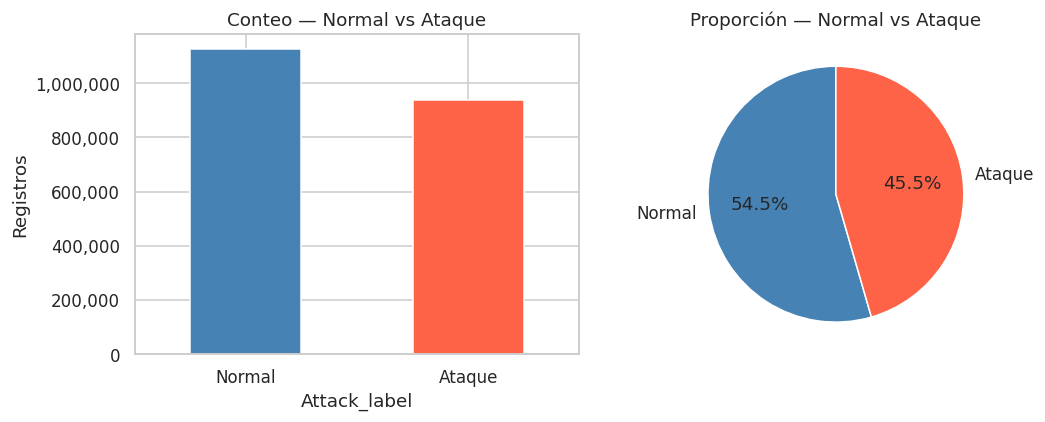

In [8]:
class_counts = df['Attack_label'].value_counts().rename({0: 'Normal', 1: 'Ataque'})
class_pct    = class_counts / class_counts.sum() * 100

summary = pd.DataFrame({'registros': class_counts, 'porcentaje': class_pct.round(2)})
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
class_counts.plot.bar(ax=axes[0], color=['steelblue', 'tomato'], rot=0)
axes[0].set_title('Conteo — Normal vs Ataque')
axes[0].set_ylabel('Registros')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Proporción — Normal vs Ataque')
plt.tight_layout()
plt.show()

## 6. Distribución por tipo de ataque

,registros
Attack_type,
Normal,1124915
DDoS_HTTP,229022
Vulnerability_scanner,145869
Password,100362
DDoS_UDP,99972
DDoS_TCP,99796
DDoS_ICMP,99563
SQL_injection,51203
Uploading,37634


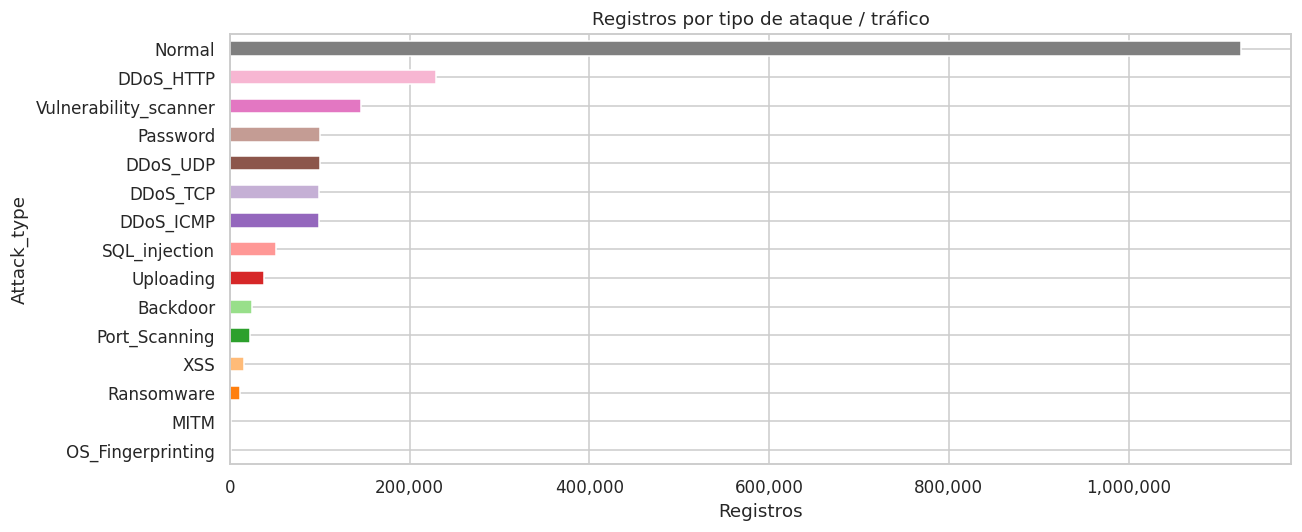

In [9]:
attack_type_counts = df['Attack_type'].value_counts()
display(attack_type_counts.rename('registros').to_frame())

fig, ax = plt.subplots(figsize=(12, 5))
attack_type_counts.sort_values().plot.barh(ax=ax, color=sns.color_palette('tab20', len(attack_type_counts)))
ax.set_xlabel('Registros')
ax.set_title('Registros por tipo de ataque / tráfico')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 7. Valores nulos

Columnas con valores nulos: 14 de 63


,nulos,pct_nulos
mqtt.hdrflags,232616,11.27
tcp.dstport,155549,7.53
tcp.ack_raw,155543,7.53
icmp.checksum,100134,4.85
mqtt.conack.flags,58089,2.81
mqtt.conflags,58097,2.81
icmp.seq_le,9448,0.46
arp.hw.size,472,0.02
tcp.srcport,376,0.02
tcp.len,389,0.02


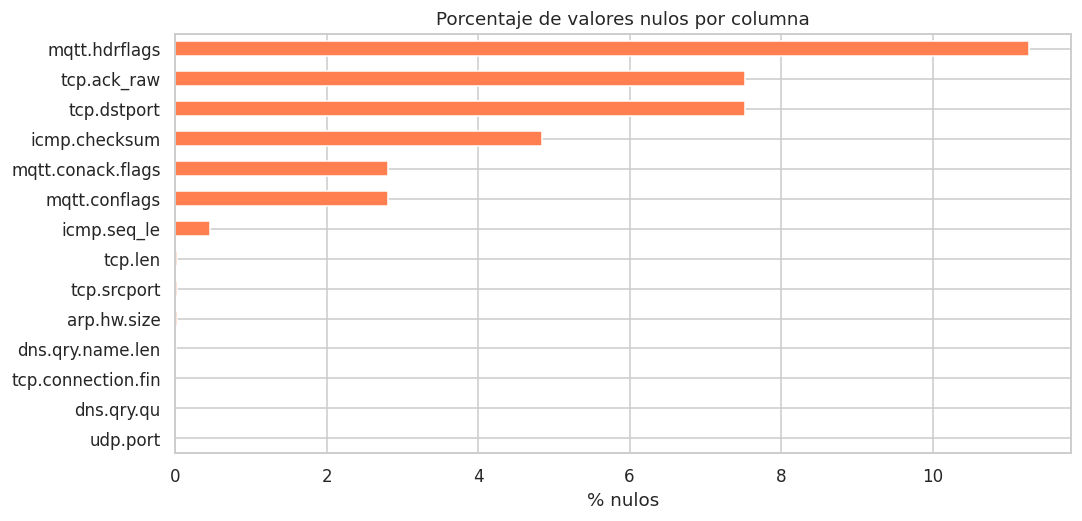

In [10]:
null_counts = df.isnull().sum()
null_pct    = null_counts / len(df) * 100
null_df = pd.DataFrame({'nulos': null_counts, 'pct_nulos': null_pct.round(2)})
null_df = null_df[null_df['nulos'] > 0].sort_values('pct_nulos', ascending=False)

print(f'Columnas con valores nulos: {len(null_df)} de {df.shape[1]}')
display(null_df.head(20))

if not null_df.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, len(null_df) * 0.35)))
    null_df['pct_nulos'].sort_values().plot.barh(ax=ax, color='coral')
    ax.set_xlabel('% nulos')
    ax.set_title('Porcentaje de valores nulos por columna')
    plt.tight_layout()
    plt.show()


NUMERIC_COLS = [
    'tcp.len', 'tcp.srcport', 'tcp.dstport',
    'udp.port', 'udp.time_delta',
    'icmp.seq_le',
    'mqtt.len', 'mqtt.msgtype',
    'mbtcp.len',
    'http.content_length',
]
cols_present = [c for c in NUMERIC_COLS if c in df.columns]
display(df[cols_present].describe().T)


In [11]:
NUMERIC_COLS = [
    'tcp.len', 'tcp.srcport', 'tcp.dstport',
    'udp.port', 'udp.time_delta',
    'icmp.seq_le',
    'mqtt.len', 'mqtt.msgtype',
    'mbtcp.len',
    'http.content_length',
]
cols_present = [c for c in NUMERIC_COLS if c in df.columns]
display(df[cols_present].describe().T)

,count,mean,std,min,25%,50%,75%,max
tcp.len,2064443.0,53.773516,393.070881,0.0,0.0,0.0,2.0,65228.000000
tcp.srcport,2064456.0,24432.443210,25919.585788,0.0,80.0,1883.0,52145.0,65535.000000
tcp.dstport,1909283.0,22114.959686,26103.331017,0.0,80.0,1883.0,51661.0,65535.000000
udp.port,2064823.0,30.033816,1211.296116,0.0,0.0,0.0,0.0,63894.000000
udp.time_delta,2064832.0,0.050810,5.001840,0.0,0.0,0.0,0.0,4008.703787
icmp.seq_le,2055384.0,1585.005187,8142.343526,0.0,0.0,0.0,0.0,65534.000000
mqtt.len,2064832.0,1.173467,5.099366,0.0,0.0,0.0,0.0,47.000000
mqtt.msgtype,2064832.0,0.563527,2.366428,0.0,0.0,0.0,0.0,14.000000
mbtcp.len,2064832.0,1158.125841,6034.410178,0.0,0.0,0.0,0.0,48900.000000
http.content_length,2064832.0,13.462687,175.437721,0.0,0.0,0.0,0.0,83655.000000


## 9. Análisis por protocolo de red

,protocolo,normal,ataque,total
3,HTTP,0,580005,580005
0,TCP,244539,313849,558388
4,MQTT,232616,0,232616
6,DNS,159635,9675,169310
5,Modbus,97947,0,97947
7,ARP,924,2853,3777
1,UDP,3263,367,3630
2,ICMP,0,0,0


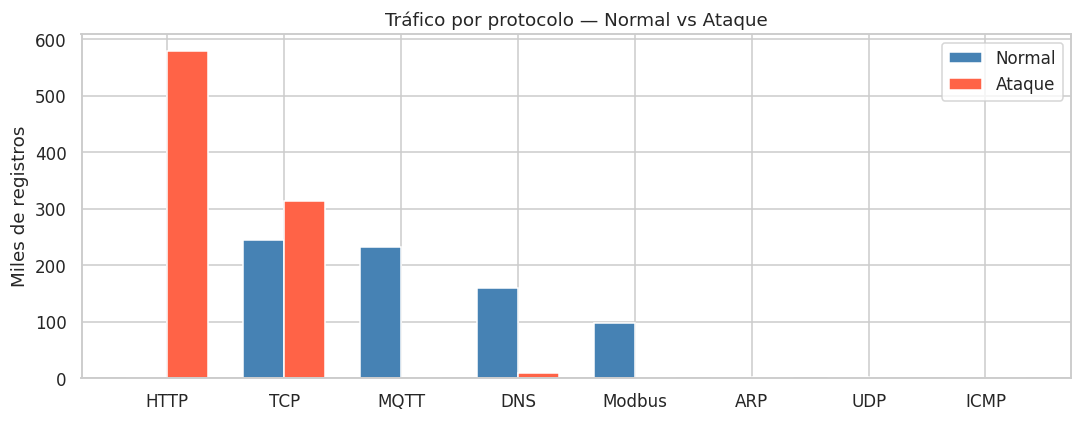

In [12]:
protocol_flags = {
    'TCP'    : df['tcp.len'].notna() & (df['tcp.len'] != 0),
    'UDP'    : df['udp.port'].notna() & (df['udp.port'] != 0),
    'ICMP'   : df['icmp.checksum'].notna() & (df['icmp.checksum'] != 0),
    'HTTP'   : df['http.request.method'].notna() & (df['http.request.method'] != 0),
    'MQTT'   : df['mqtt.msgtype'].notna() & (df['mqtt.msgtype'] != 0),
    'Modbus' : df['mbtcp.len'].notna() & (df['mbtcp.len'] != 0),
    'DNS'    : df['dns.qry.name'].notna() & (df['dns.qry.name'] != 0),
    'ARP'    : df['arp.opcode'].notna() & (df['arp.opcode'] != 0),
}

proto_rows = []
for proto, mask in protocol_flags.items():
    sub = df[mask]
    normal_n = (sub['Attack_label'] == 0).sum()
    attack_n = (sub['Attack_label'] == 1).sum()
    proto_rows.append({'protocolo': proto, 'normal': normal_n, 'ataque': attack_n, 'total': len(sub)})

proto_df = pd.DataFrame(proto_rows).sort_values('total', ascending=False)
display(proto_df)

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(proto_df))
w = 0.35
ax.bar([i - w/2 for i in x], proto_df['normal'] / 1e3, w, label='Normal', color='steelblue')
ax.bar([i + w/2 for i in x], proto_df['ataque'] / 1e3, w, label='Ataque', color='tomato')
ax.set_xticks(list(x))
ax.set_xticklabels(proto_df['protocolo'])
ax.set_ylabel('Miles de registros')
ax.set_title('Tráfico por protocolo — Normal vs Ataque')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Top IPs origen y destino

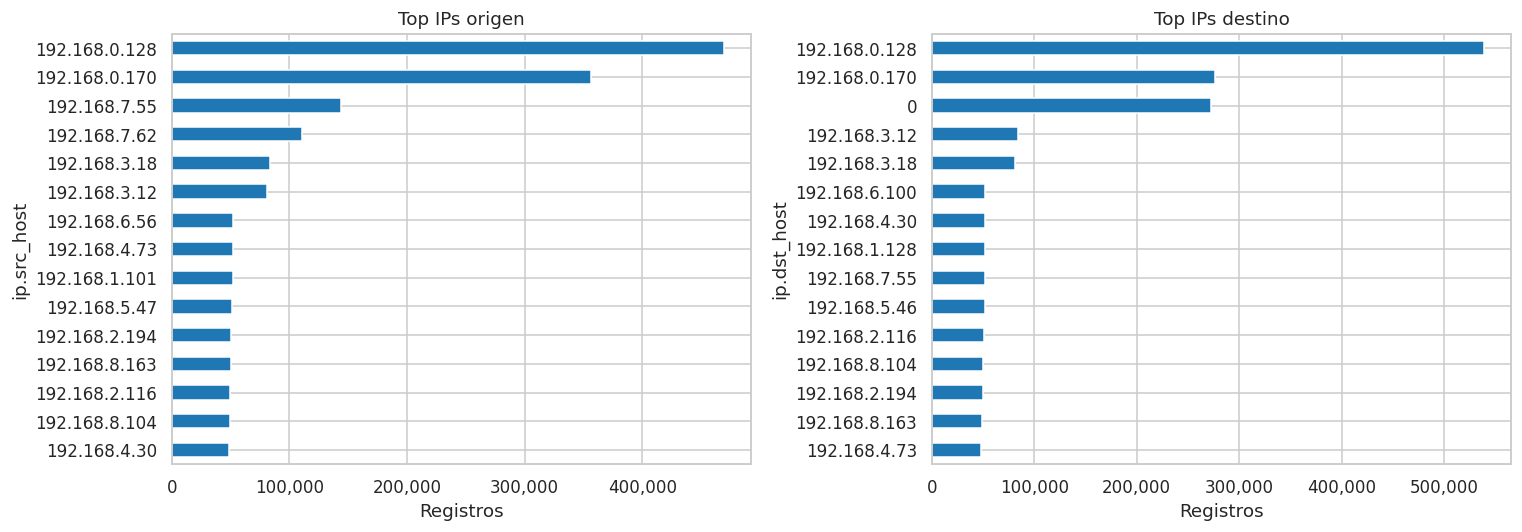

In [13]:
top_n = 15
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
                           ['ip.src_host', 'ip.dst_host'],
                           ['Top IPs origen', 'Top IPs destino']):
    counts = df[col].value_counts().head(top_n)
    counts.sort_values().plot.barh(ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Registros')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

## 11. Distribución de longitud de paquetes TCP (Normal vs Ataque)

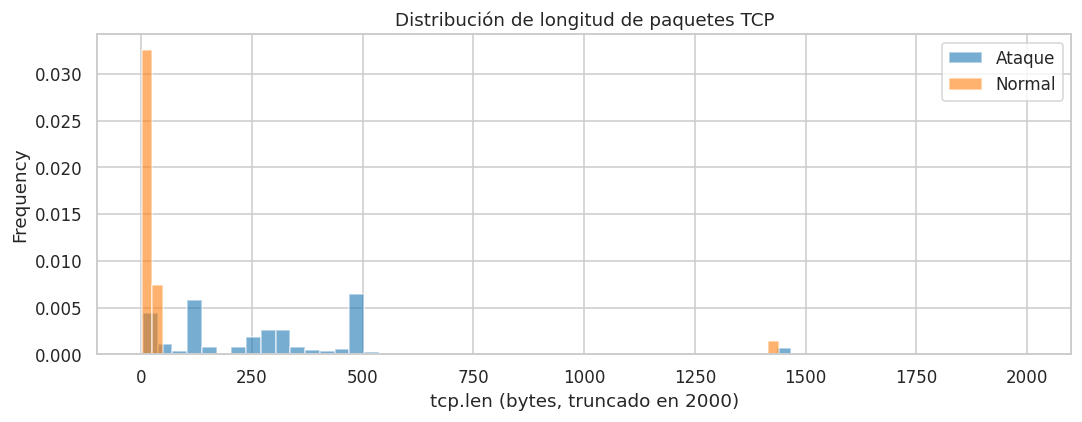

In [14]:
tcp_data = df[df['tcp.len'] > 0][['tcp.len', 'Attack_label']].copy()
tcp_data['clase'] = tcp_data['Attack_label'].map({0: 'Normal', 1: 'Ataque'})

fig, ax = plt.subplots(figsize=(10, 4))
for label, grp in tcp_data.groupby('clase'):
    grp['tcp.len'].clip(upper=2000).plot.hist(
        bins=60, alpha=0.6, ax=ax, label=label, density=True
    )
ax.set_xlabel('tcp.len (bytes, truncado en 2000)')
ax.set_title('Distribución de longitud de paquetes TCP')
ax.legend()
plt.tight_layout()
plt.show()

## 12. Correlación entre features numéricas

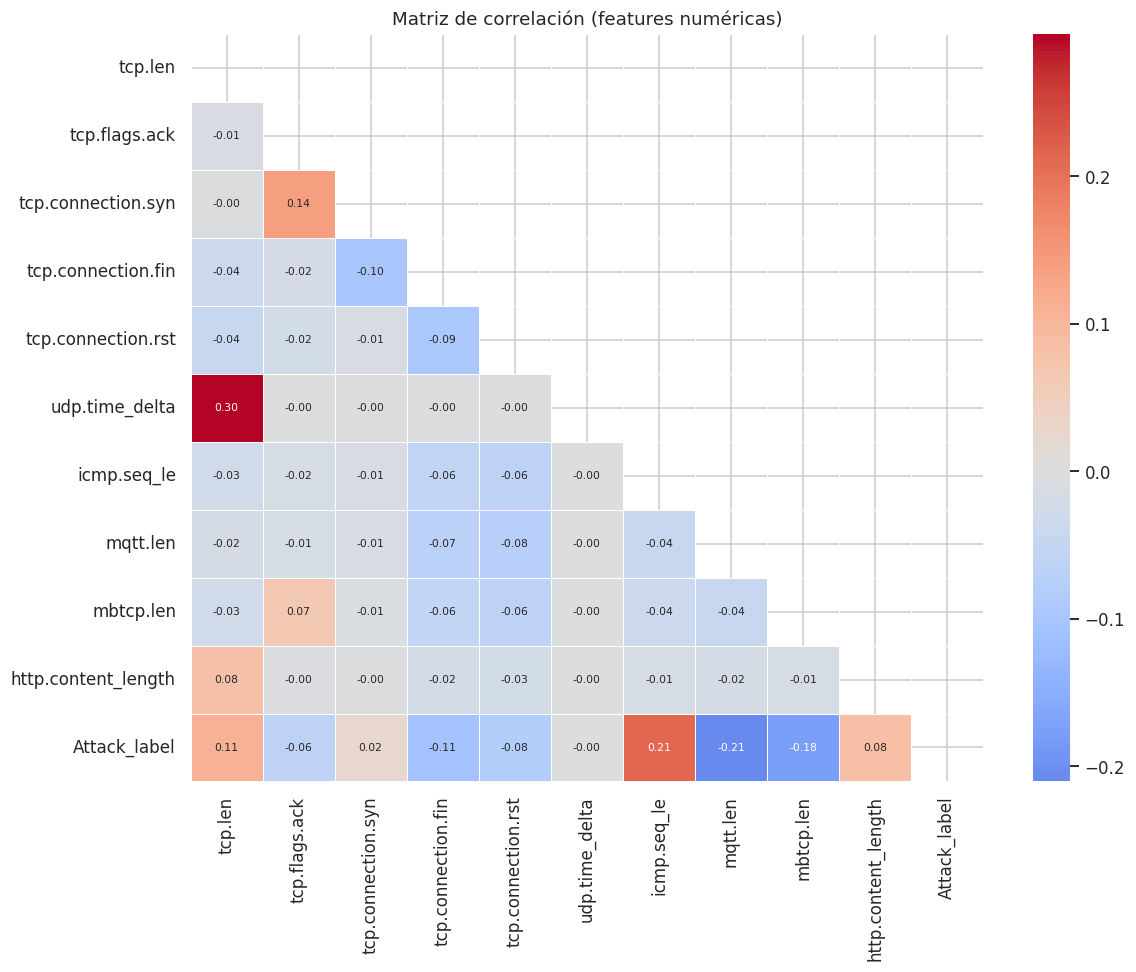

In [15]:
CORR_COLS = [
    'tcp.len', 'tcp.flags.ack', 'tcp.connection.syn', 'tcp.connection.fin', 'tcp.connection.rst',
    'udp.time_delta', 'icmp.seq_le',
    'mqtt.len', 'mbtcp.len', 'http.content_length',
    'Attack_label',
]
corr_cols_present = [c for c in CORR_COLS if c in df.columns]
corr_data = df[corr_cols_present].apply(pd.to_numeric, errors='coerce')
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size': 7})
ax.set_title('Matriz de correlación (features numéricas)')
plt.tight_layout()
plt.show()

## 13. Resumen final

In [16]:
total = len(df)
n_normal = (df['Attack_label'] == 0).sum()
n_attack = (df['Attack_label'] == 1).sum()
n_attack_types = df[df['Attack_label'] == 1]['Attack_type'].nunique()

print('=' * 45)
print('RESUMEN DEL DATASET')
print('=' * 45)
print(f'Total registros   : {total:>12,}')
print(f'Tráfico normal    : {n_normal:>12,}  ({n_normal/total*100:.1f}%)')
print(f'Tráfico de ataque : {n_attack:>12,}  ({n_attack/total*100:.1f}%)')
print(f'Tipos de ataque   : {n_attack_types:>12}')
print(f'Columnas totales  : {df.shape[1]:>12}')
print(f'Columnas con nulos: {(df.isnull().sum() > 0).sum():>12}')
print('=' * 45)

RESUMEN DEL DATASET
Total registros   :    2,064,832
Tráfico normal    :    1,124,915  (54.5%)
Tráfico de ataque :      939,917  (45.5%)
Tipos de ataque   :           14
Columnas totales  :           63


Columnas con nulos:           14
